In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import scipy as sp
from scipy import stats
# import pandas as pd
import scipy.constants as cs


ModuleNotFoundError: No module named 'pandas'

In [2]:
plt.style.use('../plots.mplstyle')

In [3]:
def single_coil(amps, radius, distance):
    return 1e4 * 69 * cs.mu_0 * amps * radius**2 / (2 * (distance**2 + radius**2)**(3/2)) # convert to G from T and 109 winds
def double_coil(amps, radius, distance, turns): # Double coil formula found here: https://wpcdn.web.wsu.edu/wp-labs/uploads/sites/147/2019/03/PDF-FILE-SOLUTION-Helmholtz-Coils-READY-FOR-WEB-PAGE-UPLOAD.pdf
    return 1e4 * amps * cs.mu_0 * radius ** 2 * turns * (1/(radius**2 + (distance/2)**2)**(3/2)) # convert to G from T

In [5]:
X = pd.read_excel('./Scope/github/experiment/coil_data/X.xlsx')
Y = pd.read_excel('./Scope/github/experiment/coil_data/Y.xlsx')
Z = pd.read_excel('./Scope/github/experiment/coil_data/Z.xlsx')

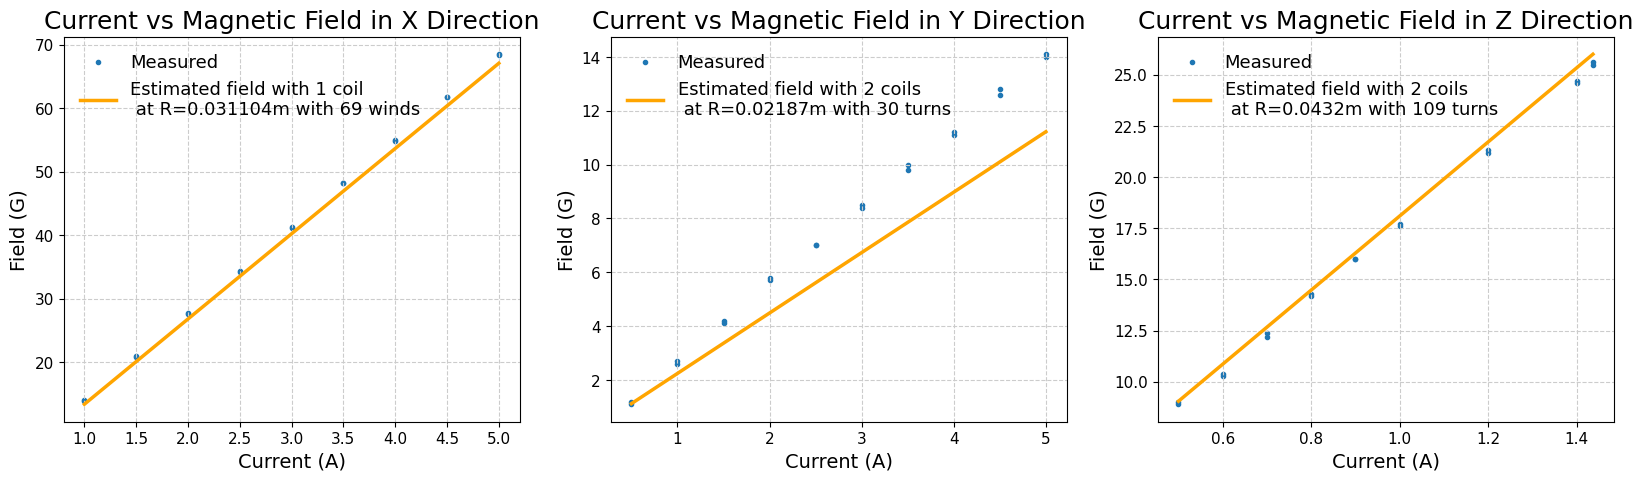

In [6]:
orientations = ['X', 'Y', 'Z']
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].scatter(X.iloc[:, 0], X.iloc[:, 1], label='Measured')
axs[0].plot(X.iloc[:, 0], single_coil(X.iloc[:, 0], radius=31.104e-3, distance=5e-3), label=f'Estimated field with 1 coil\n at R={31.104e-3}m with 69 winds', color='orange')
axs[0].set_xlabel('Current (A)')
axs[0].set_ylabel('Field (G)')
axs[0].set_title(f'Current vs Magnetic Field in {orientations[0]} Direction')
axs[0].legend()

axs[1].scatter(Y.iloc[:, 0], Y.iloc[:, 1], label='Measured')
axs[1].plot(Y.iloc[:, 0], double_coil(Y.iloc[:, 0], radius=21.87e-3, distance=74.395e-3, turns=30), label=f'Estimated field with 2 coils \n at R={21.87e-3}m with {30} turns', color='orange')
axs[1].set_xlabel('Current (A)')
axs[1].set_ylabel('Field (G)')
axs[1].set_title(f'Current vs Magnetic Field in {orientations[1]} Direction')
axs[1].legend()

axs[2].scatter(Z.iloc[:, 0], Z.iloc[:, 1], label='Measured')
axs[2].plot(Z.iloc[:, 0], double_coil(Z.iloc[:, 0], radius=43.20e-3, distance=58.18e-3, turns=109), label=f'Estimated field with 2 coils \n at R={43.20e-3}m with {109} turns', color='orange')
axs[2].set_xlabel('Current (A)')
axs[2].set_ylabel('Field (G)')
axs[2].set_title(f'Current vs Magnetic Field in {orientations[2]} Direction')
axs[2].legend()


In [8]:
# # Convert xlsx files to csv files and export them
# for i in filenames:
#     temp = pd.read_excel(i)
#     temp.to_csv(i.replace('.xlsx', '.csv'), index=False)

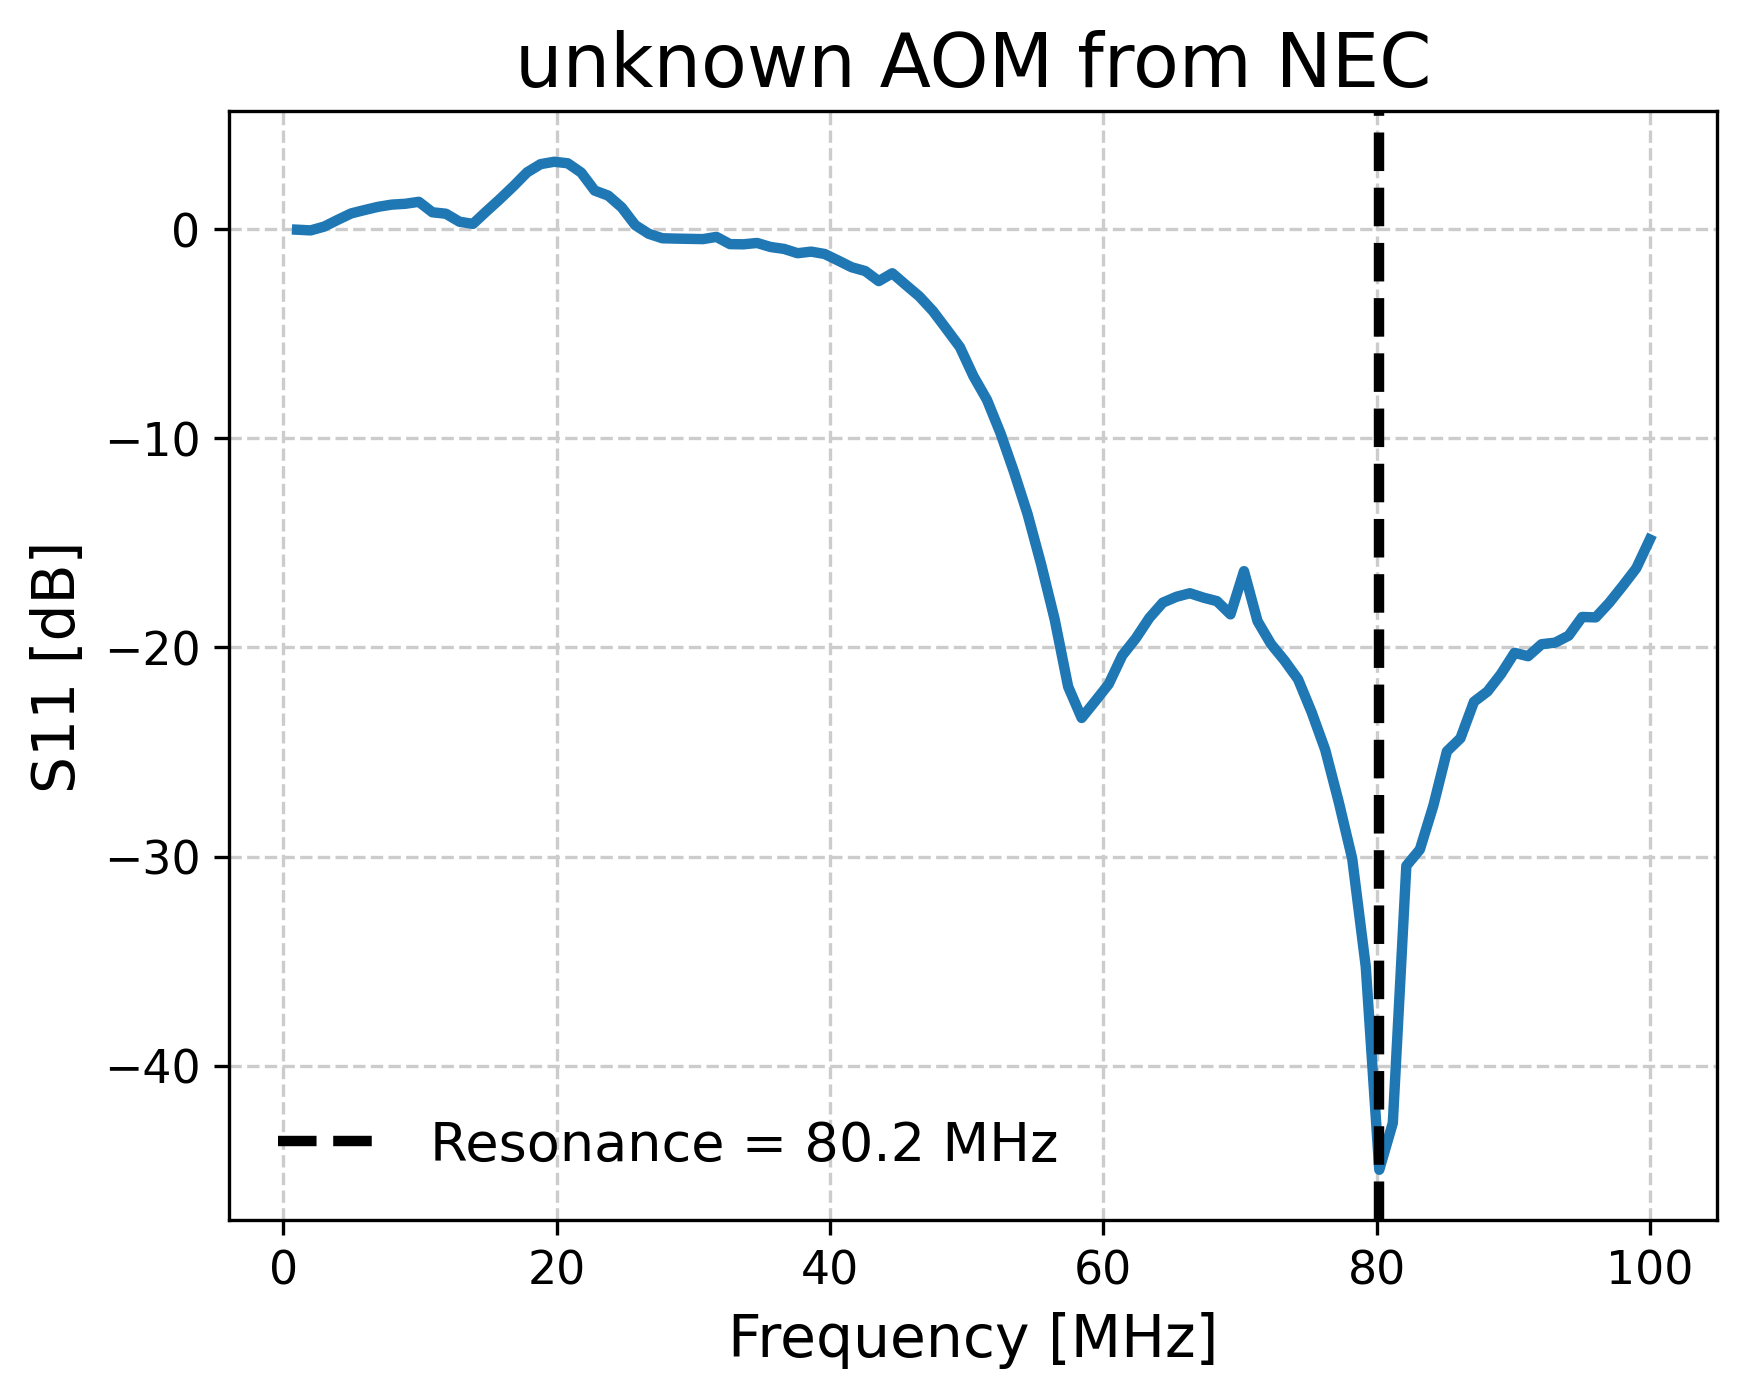

: 

In [ ]:

data = np.loadtxt("../vna/aom.s1p", comments=["#", "!"])

freq = data[:, 0] / 1e6  # MHz
re = data[:, 1]
im = data[:, 2]

s11_mag = np.sqrt(re**2 + im**2)
s11_db = 20 * np.log10(s11_mag)

dip_idx = np.argmin(s11_db)

fig, ax = plt.subplots(dpi=300)
plt.plot(freq, s11_db)
plt.title("unknown AOM from NEC")
plt.axvline(freq[dip_idx], linestyle="--",
            label=f"Resonance = {freq[dip_idx]:.1f} MHz", color="black")
plt.xlabel("Frequency [MHz]")
plt.ylabel("S11 [dB]")
plt.legend()
plt.show()